# Multi-Output Bayes by Backprop on a 1D Elastic Bar

This notebook uses a simple elastic-bar surrogate with two outputs:

- displacement $u(x)$
- axial stress $\sigma(x)$

The goal is to show how one mean-field Bayesian network can quantify predictive uncertainty over coupled mechanical outputs.


In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parents[1]
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))


In [2]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import MultiOutputBayesByBackpropRegressor, predict_vi_uq, vi_elbo_step


## Elastic-bar dataset

We use a manufactured small-strain bar response under an effective load parameter. The input is the spatial coordinate plus material and loading parameters; the targets are displacement and stress.


In [3]:
torch.manual_seed(1)
x_grid = torch.linspace(0.0, 1.0, 80).unsqueeze(-1)

def elastic_bar_outputs(x, youngs_modulus, load):
    displacement = (load / youngs_modulus) * x * (1.0 - x)
    stress = load * (0.5 - x)
    return torch.cat([displacement, stress], dim=1)

def build_dataset(n_functions, ood=False):
    rows = []
    targets = []
    for _ in range(n_functions):
        if ood:
            E = torch.empty(1).uniform_(2.5, 3.2).item()
            p = torch.empty(1).uniform_(1.4, 2.2).item()
        else:
            E = torch.empty(1).uniform_(1.2, 2.4).item()
            p = torch.empty(1).uniform_(0.4, 1.4).item()
        x = x_grid
        y = elastic_bar_outputs(x, E, p)
        features = torch.cat([x, torch.full_like(x, E), torch.full_like(x, p)], dim=1)
        rows.append(features)
        targets.append(y)
    return torch.cat(rows, dim=0), torch.cat(targets, dim=0)

x_train, y_train = build_dataset(96)
x_val, y_val = build_dataset(24)
x_test, y_test = build_dataset(24)
x_ood, y_ood = build_dataset(24, ood=True)
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=128, shuffle=True)


In [4]:
model = MultiOutputBayesByBackpropRegressor(input_dim=3, output_dim=2, hidden_dims=(64, 64), activation="tanh", prior_sigma=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
criterion = torch.nn.MSELoss(reduction="mean")

for _ in range(60):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad(set_to_none=True)
        loss, _, _ = vi_elbo_step(model, xb, yb, num_batches=len(train_loader), criterion=criterion, kl_weight=0.01)
        loss.backward()
        optimizer.step()


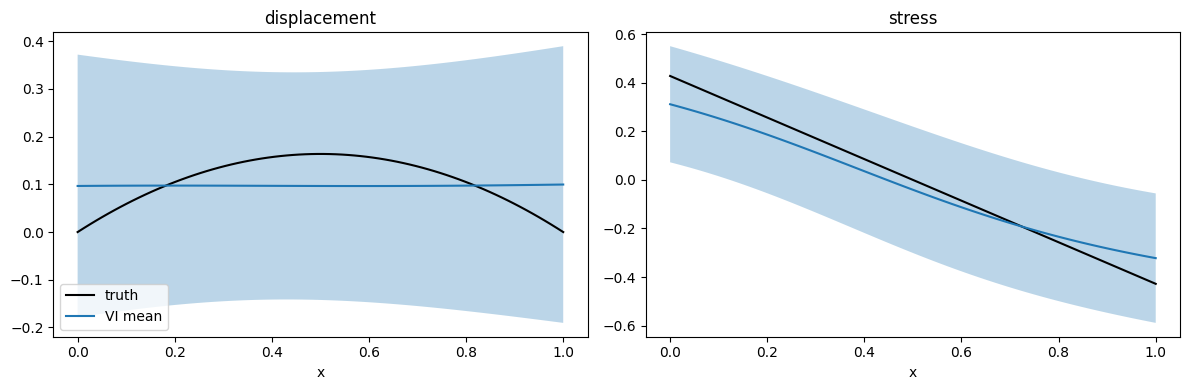

In [5]:
uq = predict_vi_uq(model, x_test, n_samples=40)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
idx = slice(0, x_grid.shape[0])
labels = ["displacement", "stress"]
for j, ax in enumerate(axes):
    ax.plot(x_test[idx, 0], y_test[idx, j], color="black", label="truth")
    ax.plot(x_test[idx, 0], uq.mean[idx, j], color="tab:blue", label="VI mean")
    std = uq.total_var[idx, j].sqrt()
    ax.fill_between(x_test[idx, 0], uq.mean[idx, j] - 2 * std, uq.mean[idx, j] + 2 * std, alpha=0.3)
    ax.set_title(labels[j])
    ax.set_xlabel("x")
axes[0].legend(loc="best")
plt.tight_layout()
